In [1]:
# ============================================
# Stage 3 – Dual-Token Fusion (RGB + FFT on Input)
# Full fine-tuning with DeepfakeBench metrics
# ============================================

import os, random, torch, torch.nn as nn, torch.optim as optim
import numpy as np
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.fft as fft
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from PIL import Image
from io import BytesIO
import warnings
import torch.nn.functional as F
warnings.filterwarnings("ignore")

In [2]:
import random, numpy as np, torch

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

In [3]:
!pip install facenet-pytorch==2.5.3 --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.6 MB/s eta 0:00:00


In [4]:
from facenet_pytorch import MTCNN
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import torch
import shutil

device = 'cuda' if torch.cuda.is_available() else 'cpu'

mtcnn = MTCNN(
    image_size=224,
    margin=40,
    device=device,
    post_process=False
)

SRC_ROOT = Path("/kaggle/input/datasets/hooriyamasood/faceforensics-c23/FaceForensics-c40_frames-Split")
DST_ROOT = Path("/kaggle/working/FF_aligned_faces")

splits = ["train", "val", "test"]
manips = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]

# reset output so old bad folders don't remain
if DST_ROOT.exists():
    shutil.rmtree(DST_ROOT)

def save_aligned(src_img_path, dst_img_path):
    try:
        img = Image.open(src_img_path).convert("RGB")
        face = mtcnn(img)

        dst_img_path.parent.mkdir(parents=True, exist_ok=True)

        if face is None:
            img = img.resize((224, 224))
            img.save(dst_img_path)
        else:
            face = face.permute(1, 2, 0).contiguous()
            if face.max() <= 1.5:
                face = face * 255.0
            face = face.clamp(0, 255).byte().cpu().numpy()
            Image.fromarray(face).save(dst_img_path)
    except Exception as e:
        pass

for split in splits:
    # REAL
    real_src = SRC_ROOT / split / "real"
    real_dst = DST_ROOT / split / "real"

    for video_dir in tqdm(sorted(real_src.iterdir()), desc=f"{split} real"):
        if not video_dir.is_dir():
            continue
        for img_path in video_dir.glob("*"):
            if img_path.is_file():
                dst_path = real_dst / video_dir.name / img_path.name
                save_aligned(img_path, dst_path)

    # FAKE
    fake_src = SRC_ROOT / split / "fake"
    fake_dst = DST_ROOT / split / "fake"

    for manip in manips:
        manip_src = fake_src / manip
        manip_dst = fake_dst / manip

        if not manip_src.exists():
            print(f"Missing manip folder: {manip_src}")
            continue

        for video_dir in tqdm(sorted(manip_src.iterdir()), desc=f"{split} {manip}"):
            if not video_dir.is_dir():
                continue
            for img_path in video_dir.glob("*"):
                if img_path.is_file():
                    dst_path = manip_dst / video_dir.name / img_path.name
                    save_aligned(img_path, dst_path)

print("Alignment finished.")

test NeuralTextures: 100%|██████████| 100/100 [01:29<00:00,  1.12it/s]

Alignment finished.


In [5]:
from pathlib import Path

for split in ["train", "val", "test"]:
    root = Path(f"/kaggle/working/FF_aligned_faces/{split}")
    print(f"\n{split.upper()}")
    print("real:", len(list((root / "real").glob("*"))))
    for m in ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]:
        print(m, len(list((root / "fake" / m).glob("*"))))


TRAIN
real: 800
Deepfakes 800
Face2Face 800
FaceSwap 800
NeuralTextures 800

VAL
real: 100
Deepfakes 100
Face2Face 100
FaceSwap 100
NeuralTextures 100

TEST
real: 100
Deepfakes 100
Face2Face 100
FaceSwap 100
NeuralTextures 100


In [6]:
# ---- DeepfakeBench metric helper ----
def calc_metrics(y_true, y_prob):
    y_pred = (y_prob > 0.5).astype(int)
    auc  = roc_auc_score(y_true, y_prob)
    f1   = f1_score(y_true, y_pred)
    acc  = accuracy_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    eer  = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    return auc, f1, eer, acc

In [7]:
import random
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms.functional as TF
from torchvision import transforms
from io import BytesIO

# --- your JPEG aug ---
class RandomJPEG:
    def __init__(self, quality_min=30, quality_max=100, p=0.7):
        self.quality_min = quality_min
        self.quality_max = quality_max
        self.p = p

    def __call__(self, img: Image.Image):
        if random.random() > self.p:
            return img
        q = random.randint(self.quality_min, self.quality_max)
        buf = BytesIO()
        img.save(buf, format="JPEG", quality=q)
        buf.seek(0)
        return Image.open(buf).convert("RGB")

class FFPPVideoFramesDataset(Dataset):
    def __init__(self, root, compression="c23", manips=None,
                 train=True, p_flip=0.5,
                 jpeg_aug=None, rgb_color_aug=None, rgb_norm=None):
        self.root = Path(root)
        self.comp = compression
        self.train = train
        self.p_flip = p_flip
        self.jpeg_aug = jpeg_aug
        self.rgb_color_aug = rgb_color_aug
        self.rgb_norm = rgb_norm
        self.class_to_idx = {"real": 0, "fake": 1}

        if manips is None:
            manips = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]
        self.manips = manips

        self.samples = []  # list of dicts: {label, frames_dir, manip}

        # real videos
        real_base = self.root / "real"
        for vid_dir in sorted(real_base.glob("*")):
            if vid_dir.is_dir():
                self.samples.append({"label": 0, "frames_dir": vid_dir, "manip": "real"})

        # fake videos

        fake_base = self.root / "fake"
        for m in self.manips:
            m_base = fake_base / m
            for vid_dir in sorted(m_base.glob("*")):
                if vid_dir.is_dir():
                    self.samples.append({"label": 1, "frames_dir": vid_dir, "manip": m})

        # pre-list frames for speed (optional but nice)
        self.frame_cache = {}
        for s in self.samples:
            frames = sorted(list(s["frames_dir"].glob("*.jpg")) + list(s["frames_dir"].glob("*.png")) + list(s["frames_dir"].glob("*.jpeg")))
            self.frame_cache[str(s["frames_dir"])] = frames

        print(f"[FFPPVideoFramesDataset] samples={len(self.samples)} | real={sum(x['label']==0 for x in self.samples)} | fake={sum(x['label']==1 for x in self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        frames = self.frame_cache[str(s["frames_dir"])]

        # pick one random frame per video (or deterministic if eval)
        if self.train:
            fpath = random.choice(frames)
        else:
            # stable evaluation: always pick the middle frame
            fpath = frames[len(frames)//2]

        img = Image.open(fpath).convert("RGB")

        # shared geometry aug
        if self.train and random.random() < self.p_flip:
            img = TF.hflip(img)

        # shared jpeg
        img_jpeg = self.jpeg_aug(img) if (self.train and self.jpeg_aug is not None) else img

        # RAW view
        x_raw = TF.to_tensor(img_jpeg)

        # RGB view
        img_rgb = self.rgb_color_aug(img_jpeg) if (self.train and self.rgb_color_aug is not None) else img_jpeg
        x_rgb = TF.to_tensor(img_rgb)
        if self.rgb_norm is not None:
            x_rgb = self.rgb_norm(x_rgb)

        y = s["label"]
        return x_rgb, x_raw, y

def make_balanced_sampler(dataset: FFPPVideoFramesDataset, balance_fake_types=True):
    """
    Returns WeightedRandomSampler that:
    - balances real vs fake
    - optionally balances fake types across manipulations
    """
    # Count groups
    real_idxs = [i for i,s in enumerate(dataset.samples) if s["label"] == 0]
    fake_by_manip = {}
    for i,s in enumerate(dataset.samples):
        if s["label"] == 1:
            fake_by_manip.setdefault(s["manip"], []).append(i)

    weights = [0.0] * len(dataset)

    # Target: 50/50 real/fake
    # Give all real samples equal total weight = 0.5
    w_real = 0.5 / max(len(real_idxs), 1)
    for i in real_idxs:
        weights[i] = w_real

    # For fake: total weight = 0.5
    if not balance_fake_types:
        fake_idxs = [i for i,s in enumerate(dataset.samples) if s["label"] == 1]
        w_fake = 0.5 / max(len(fake_idxs), 1)
        for i in fake_idxs:
            weights[i] = w_fake
    else:
        # Split fake weight equally across manip types
        manips = list(fake_by_manip.keys())
        per_manip_total = 0.5 / max(len(manips), 1)
        for m, idxs in fake_by_manip.items():
            w = per_manip_total / max(len(idxs), 1)
            for i in idxs:
                weights[i] = w

    return WeightedRandomSampler(torch.DoubleTensor(weights), num_samples=len(weights), replacement=True)

In [8]:
class GlobalFilter(nn.Module):
    """
    Learnable complex filter applied in frequency domain.
    Expects fixed H,W feature map size (e.g., 28x28).
    """
    def __init__(self, dim, h, w, fp32fft=True):
        super().__init__()
        self.h = h
        self.w = w
        self.fp32fft = fp32fft

        # rfft2 width is (w//2 + 1)
        self.complex_weight = nn.Parameter(
            torch.randn(h, w // 2 + 1, dim, 2, dtype=torch.float32) * 0.02
        )

    def forward(self, x):
        # x: [B,C,H,W] where H,W match self.h,self.w
        B, C, H, W = x.shape
        assert H == self.h and W == self.w, f"Expected {self.h}x{self.w}, got {H}x{W}"

        x = x.permute(0, 2, 3, 1).contiguous()  # [B,H,W,C]

        if self.fp32fft:
            orig_dtype = x.dtype
            x = x.float()

        x_f = torch.fft.rfft2(x, dim=(1, 2), norm="ortho")  # [B,H,W//2+1,C]
        w = torch.view_as_complex(self.complex_weight)      # [H,W//2+1,C]
        x_f = x_f * w

        x = torch.fft.irfft2(x_f, s=(H, W), dim=(1, 2), norm="ortho")  # [B,H,W,C]

        if self.fp32fft:
            x = x.to(orig_dtype)

        x = x.permute(0, 3, 1, 2).contiguous()  # [B,C,H,W]
        return x

In [9]:
class Stage3Hybrid(nn.Module):
    def __init__(self, embed_dim=512, num_heads=8, num_layers=4, use_fft=True, grid=10):
        super().__init__()
        self.use_fft = use_fft
        self.grid = grid
        self.freq_filter = GlobalFilter(dim=512, h=28, w=28, fp32fft=True)

        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        self.proj_rgb = nn.Conv2d(2048, embed_dim, 1)
        self.proj_fft = nn.Conv2d(512, embed_dim, 1)

        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.type_embed = nn.Parameter(torch.randn(1, 2, embed_dim))

        num_tokens = 1 + 2 * (grid * grid)
        self.pos_embed = nn.Parameter(torch.randn(1, num_tokens, embed_dim))

        self.cls_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 2)
        )

    def forward(self, x_rgb, x_raw=None, return_aux=False):
        B = x_rgb.size(0)
        G = self.grid

        x = self.stem(x_rgb)
        x = self.layer1(x)
        feat_l2 = self.layer2(x)              # [B,512,28,28]
        x = self.layer3(feat_l2)
        feat_l4 = self.layer4(x)              # [B,2048,7,7]

        rgb_map = self.proj_rgb(feat_l4)      # [B,E,7,7]
        rgb_map_g = F.adaptive_avg_pool2d(rgb_map, (G, G))
        rgb_tok = rgb_map_g.flatten(2).transpose(1, 2)

        if self.use_fft:
            freq_feat = self.freq_filter(feat_l2)          # [B,512,28,28]
            fft_map = self.proj_fft(freq_feat)             # [B,E,28,28]
            fft_map_g = F.adaptive_avg_pool2d(fft_map, (G, G))
            fft_tok = fft_map_g.flatten(2).transpose(1, 2)
        else:
            freq_feat = torch.zeros_like(feat_l2)
            fft_map = torch.zeros(B, rgb_map.shape[1], 28, 28, device=x_rgb.device, dtype=rgb_map.dtype)
            fft_map_g = torch.zeros_like(rgb_map_g)
            fft_tok = torch.zeros_like(rgb_tok)

        rgb_tok = rgb_tok + self.type_embed[:, 0:1, :]
        fft_tok = fft_tok + self.type_embed[:, 1:2, :]

        rgb_tok_before = rgb_tok.clone()

        fused_rgb, attn = self.cross_attn(
            query=rgb_tok,
            key=fft_tok,
            value=fft_tok,
            need_weights=True,
            average_attn_weights=False
        )
        rgb_tok = rgb_tok + fused_rgb

        cls = self.cls_token.repeat(B, 1, 1)
        tokens = torch.cat([cls, rgb_tok, fft_tok], dim=1)
        tokens = tokens + self.pos_embed[:, :tokens.size(1), :]

        out = self.transformer(tokens)
        cls_out = out[:, 0]
        logits = self.cls_head(cls_out)

        if not return_aux:
            return logits

        aux = {
            "feat_l4": feat_l4,
            "rgb_map_g": rgb_map_g,
            "fft_map_g": fft_map_g,
            "fused_rgb": fused_rgb,
            "rgb_tok_before": rgb_tok_before,
            "attn": attn,
        }
        return logits, aux

In [10]:
def evaluate(model, loader, class_to_idx, tag="EVAL"):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()

    fake_idx = class_to_idx["fake"]  # positive class
    y_true, y_prob = [], []

    with torch.no_grad():
        for x_rgb, x_raw, lbls in tqdm(loader, desc=tag, ncols=100):
            x_rgb = x_rgb.to(device, non_blocking=True)
            logits = model(x_rgb, x_raw=None)
            probs_fake = torch.softmax(logits, dim=1)[:, fake_idx].cpu().numpy()

            lbls_np = lbls.numpy()
            y_true.extend((lbls_np == fake_idx).astype(np.int32))
            y_prob.extend(probs_fake)

    auc, f1, eer, acc = calc_metrics(np.array(y_true), np.array(y_prob))
    print(f"{tag} → AUROC={auc:.3f} | F1={f1:.3f} | EER={eer:.3f} | ACC={acc:.3f}")
    return auc, f1, eer, acc

In [11]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR


def finetune(pretrained_ckpt_path,
                  train_root, val_root, test_root,
                  epochs=15, freeze_epochs=1, batch_size=16):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = Stage3Hybrid().to(device)

    state = torch.load(pretrained_ckpt_path, map_location="cpu")
    model.load_state_dict(state, strict=True)
    print("Loaded pretrained:", pretrained_ckpt_path)

   # ---- augs ----
    jpeg_aug = RandomJPEG(p=0.3, quality_min=60, quality_max=95)
    rgb_color_aug = transforms.ColorJitter(0.08, 0.08, 0.04, 0.02)
    rgb_norm = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    
    
    trainset = FFPPVideoFramesDataset(train_root, compression="c23", train=True,
                                  jpeg_aug=jpeg_aug, rgb_color_aug=rgb_color_aug, rgb_norm=rgb_norm)
    
    valset   = FFPPVideoFramesDataset(val_root, compression="c23", train=False,
                                      jpeg_aug=None, rgb_color_aug=None, rgb_norm=rgb_norm)
    
    testset  = FFPPVideoFramesDataset(test_root, compression="c23", train=False,
                                      jpeg_aug=None, rgb_color_aug=None, rgb_norm=rgb_norm)

    # Balanced sampler for training

    sampler = make_balanced_sampler(trainset, balance_fake_types=True)
    trainloader = DataLoader(trainset, batch_size=batch_size, sampler=sampler, num_workers=2)
    valloader   = DataLoader(valset,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
    testloader  = DataLoader(testset,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

    class_to_idx = trainset.class_to_idx
    print("class_to_idx:", class_to_idx)
    fake_idx = class_to_idx["fake"]

    # backbone/head params
    backbone_params = (
        list(model.stem.parameters()) +
        list(model.layer1.parameters()) +
        list(model.layer2.parameters()) +
        list(model.layer3.parameters()) +
        list(model.layer4.parameters())
    )
    
    head_params = [
        p for n, p in model.named_parameters()
        if not (
            n.startswith("stem.") or
            n.startswith("layer1.") or
            n.startswith("layer2.") or
            n.startswith("layer3.") or
            n.startswith("layer4.")
        )
    ]
    
    opt = optim.AdamW([
        {"params": backbone_params, "lr": 1e-5},
        {"params": head_params,     "lr": 7e-5},
    ], weight_decay=5e-4)
    
    scheduler = CosineAnnealingLR(opt, T_max=epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    
    use_cuda = torch.cuda.is_available()
    scaler = torch.amp.GradScaler(enabled=use_cuda)

    best_auc = -1.0

    for epoch in range(epochs):
        # freeze warmup
        if epoch < freeze_epochs:
            for p in backbone_params:
                p.requires_grad = False
        else:
            for p in backbone_params:
                p.requires_grad = True

        model.train()
        running_loss = 0.0

        for x_rgb, x_raw, lbls in tqdm(trainloader, desc=f"FT {epoch+1}/{epochs}", ncols=100):
            x_rgb = x_rgb.to(device, non_blocking=True)
            lbls  = lbls.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type="cuda", enabled=use_cuda):
                logits = model(x_rgb, x_raw=None)
                loss = criterion(logits, lbls)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

            running_loss += float(loss.item())

        # validate (fake positive)
        model.eval()
        y_true, y_prob = [], []
        with torch.no_grad():
            for x_rgb, x_raw, lbls in valloader:
                x_rgb = x_rgb.to(device, non_blocking=True)
                logits = model(x_rgb, x_raw=None)
                probs_fake = torch.softmax(logits, dim=1)[:, fake_idx].cpu().numpy()
                lbls_np = lbls.numpy()
                y_true.extend((lbls_np == fake_idx).astype(np.int32))
                y_prob.extend(probs_fake)

        auc, f1, eer, acc = calc_metrics(np.array(y_true), np.array(y_prob))
        print(f"Epoch {epoch+1}: loss={running_loss/len(trainloader):.4f} | "
              f"AUROC={auc:.3f} | F1={f1:.3f} | EER={eer:.3f} | ACC={acc:.3f}")

        # step scheduler once per epoch
        scheduler.step()
        print("LRs:", [pg["lr"] for pg in opt.param_groups])

        # save best
        if auc > best_auc:
            best_auc = auc
            torch.save(model.state_dict(), "/kaggle/working/best_cls_ffpp.pth")
            print(f"★ New best AUC {best_auc:.3f}")

    # final test with best
    model.load_state_dict(torch.load("/kaggle/working/best_cls_ffpp.pth", map_location=device))
    evaluate(model, testloader, class_to_idx, tag="FF++ TEST")

    return model, class_to_idx

In [12]:
from pathlib import Path

pretrained_ckpt = "/kaggle/input/models/hooriyamasood/140k-m2tr-face-alignment/pytorch/default/1/best_auc_stage3.pth"
train_root = "/kaggle/working/FF_aligned_faces/train"
val_root   = "/kaggle/working/FF_aligned_faces/val"
test_root  = "/kaggle/working/FF_aligned_faces/test"

print("real videos:", len(list(Path(train_root + "/real").glob("*"))))
print("fake deepfakes:", len(list(Path(train_root + "/fake/Deepfakes").glob("*"))))

model_cls, class_to_idx = finetune(pretrained_ckpt, train_root, val_root, test_root)

real videos: 800
fake deepfakes: 800
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


Loaded pretrained: /kaggle/input/models/hooriyamasood/140k-m2tr-face-alignment/pytorch/default/1/best_auc_stage3.pth
[FFPPVideoFramesDataset] samples=4000 | real=800 | fake=3200
[FFPPVideoFramesDataset] samples=500 | real=100 | fake=400
[FFPPVideoFramesDataset] samples=500 | real=100 | fake=400
class_to_idx: {'real': 0, 'fake': 1}


FT 1/15: 100%|████████████████████████████████████████████████████| 250/250 [00:28<00:00,  8.78it/s]


Epoch 1: loss=0.8718 | AUROC=0.540 | F1=0.280 | EER=0.470 | ACC=0.300
LRs: [9.890738003669029e-06, 6.923516602568319e-05]
★ New best AUC 0.540


...

Epoch 14: loss=0.3707 | AUROC=0.913 | F1=0.912 | EER=0.170 | ACC=0.862
LRs: [1.092619963309716e-07, 7.648339743168008e-07]
★ New best AUC 0.913


FT 15/15: 100%|███████████████████████████████████████████████████| 250/250 [00:44<00:00,  5.56it/s]


Epoch 15: loss=0.3758 | AUROC=0.914 | F1=0.913 | EER=0.175 | ACC=0.864
LRs: [0.0, 0.0]
★ New best AUC 0.914


FF++ TEST: 100%|████████████████████████████████████████████████████| 32/32 [00:01<00:00, 18.77it/s]

FF++ TEST → AUROC=0.907 | F1=0.903 | EER=0.180 | ACC=0.850


In [13]:
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.14 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 17.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.23 requires protobuf>=5.29.5, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
ydf 0.14.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 whic

In [14]:
import mediapipe as mp
print(mp.__file__)
print(hasattr(mp, "solutions"))

2026-03-25 08:46:15.957044: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774428376.183039      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774428376.239622      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774428376.763650      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774428376.763696      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774428376.763700      23 computation_placer.cc:177] computation placer alr

/usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py
True


In [15]:
mp_face_mesh = mp.solutions.face_mesh

_FACE_MESH = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5
)

def get_face_mesh_points(img01):
    """
    img01: [H,W,3] float in [0,1]
    returns np.array [N,2] in pixel coords, or None
    """
    H, W = img01.shape[:2]
    img_u8 = (img01 * 255).astype(np.uint8)
    res = _FACE_MESH.process(img_u8)

    if not res.multi_face_landmarks:
        return None

    lm = res.multi_face_landmarks[0]
    pts = []
    for p in lm.landmark:
        x = int(np.clip(p.x * W, 0, W - 1))
        y = int(np.clip(p.y * H, 0, H - 1))
        pts.append([x, y])
    return np.array(pts, dtype=np.int32)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1774428397.678119     373 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [16]:
def polygon_mask_from_points(shape_hw, pts, idxs):
    H, W = shape_hw
    mask = np.zeros((H, W), dtype=np.uint8)
    poly = pts[np.array(idxs, dtype=np.int32)]
    cv2.fillConvexPoly(mask, poly, 255)
    return mask

def build_face_region_prior(img01):
    """
    Returns soft prior mask [H,W] in [0,1]
    using coarse facial regions from face mesh.
    """
    H, W = img01.shape[:2]
    pts = get_face_mesh_points(img01)

    if pts is None:
        # fallback: soft central ellipse
        yy, xx = np.mgrid[0:H, 0:W]
        cx, cy = W / 2.0, H / 2.0
        rx, ry = W * 0.33, H * 0.40
        prior = ((((xx - cx) / rx) ** 2 + ((yy - cy) / ry) ** 2) <= 1.0).astype(np.float32)
        return cv2.GaussianBlur(prior, (21, 21), 0)

    # coarse regions:
    # face oval-ish subset
    face_oval = [
        10, 338, 297, 332, 284, 251, 389, 356, 454, 323,
        361, 288, 397, 365, 379, 378, 400, 377, 152, 148,
        176, 149, 150, 136, 172, 58, 132, 93, 234, 127,
        162, 21, 54, 103, 67, 109
    ]

    left_eye = [33, 133, 160, 159, 158, 157, 173, 153, 144, 145]
    right_eye = [362, 263, 387, 386, 385, 384, 398, 373, 374, 380]
    mouth = [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291]
    nose = [6, 197, 195, 5, 4, 1, 19, 94, 2, 98, 327]

    face_mask = polygon_mask_from_points((H, W), pts, face_oval)
    left_eye_mask = polygon_mask_from_points((H, W), pts, left_eye)
    right_eye_mask = polygon_mask_from_points((H, W), pts, right_eye)
    mouth_mask = polygon_mask_from_points((H, W), pts, mouth)
    nose_mask = polygon_mask_from_points((H, W), pts, nose)

    prior = np.zeros((H, W), dtype=np.float32)

    # base face area
    prior += 0.45 * (face_mask > 0).astype(np.float32)

    # emphasise manipulation-prone regions
    prior += 0.20 * (left_eye_mask > 0).astype(np.float32)
    prior += 0.20 * (right_eye_mask > 0).astype(np.float32)
    prior += 0.25 * (mouth_mask > 0).astype(np.float32)
    prior += 0.15 * (nose_mask > 0).astype(np.float32)

    prior = np.clip(prior, 0.0, 1.0)
    prior = cv2.GaussianBlur(prior, (21, 21), 0)
    prior = prior / (prior.max() + 1e-6)
    return prior

In [17]:
def build_face_parsing_like_mask(img01, fused, fake_label=True):
    """
    img01: [224,224,3] float RGB in [0,1]
    fused: [224,224] float in [0,1]
    returns pseudo_mask in {-100,0,1}
    """
    H, W = fused.shape

    if not fake_label:
        return np.zeros((H, W), dtype=np.int64)

    face_prior = build_face_region_prior(img01)

    # combine FFT-aware fused map with face-region prior
    score = 0.80 * fused + 0.20 * face_prior
    score = norm2d_np(score)

    # confident fg/bg thresholds
    hi = np.quantile(score, 0.88)
    lo = np.quantile(score, 0.18)
    
    pseudo = np.full((H, W), -100, dtype=np.int64)
    pseudo[score >= hi] = 1
    pseudo[score <= lo] = 0

    # suppress non-face background aggressively
    outside_face = face_prior < 0.10
    pseudo[outside_face & (score <= 0.40)] = 0

    return pseudo

In [18]:
import cv2
import numpy as np
import torch

def build_fft_rgb_fused_map(img01, fft_map, delta_map, attn_map):
    gray = cv2.cvtColor((img01 * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    rgb_sal = norm2d_np(np.sqrt(gx * gx + gy * gy))

    # keep FFT dominant
    fused = 0.20 * rgb_sal + 0.45 * fft_map + 0.20 * delta_map + 0.15 * attn_map
    fused = norm2d_np(fused)
    return fused

def pseudo_mask_to_token_targets(pseudo_mask, grid=10):
    H, W = pseudo_mask.shape
    h_step = H // grid
    w_step = W // grid
    t = np.full((grid, grid), -100, dtype=np.int64)

    for r in range(grid):
        for c in range(grid):
            patch = pseudo_mask[r*h_step:(r+1)*h_step, c*w_step:(c+1)*w_step]
            vals, counts = np.unique(patch, return_counts=True)
            vc = dict(zip(vals.tolist(), counts.tolist()))

            pos = vc.get(1, 0)
            neg = vc.get(0, 0)
            area = patch.size

            if pos / max(area, 1) >= 0.40:
                t[r, c] = 1
            elif neg / max(area, 1) >= 0.65:
                t[r, c] = 0
            else:
                t[r, c] = -100

    return t.reshape(-1)

In [19]:
import cv2
import numpy as np

def denorm_rgb_tensor(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(3,1,1)
    y = (x * std) + mean
    y = y.clamp(0, 1)
    return y.permute(1,2,0).detach().cpu().numpy()

def norm2d_np(x):
    x = x.astype(np.float32)
    x = x - x.min()
    x = x / (x.max() + 1e-6)
    return x


@torch.no_grad()
def build_superpixel_token_labels(x_rgb, lbls, aux, fake_idx=1, grid=10):
    B = x_rgb.size(0)

    fft_energy = torch.norm(aux["fft_map_g"], dim=1).detach().cpu().numpy()
    fusion_delta = torch.norm(aux["fused_rgb"], dim=-1).view(B, grid, grid).detach().cpu().numpy()
    attn_mean = aux["attn"].mean(dim=1).detach().cpu().numpy()
    attn_max = attn_mean.max(axis=-1).reshape(B, grid, grid)

    token_targets = torch.full((B, grid * grid), -100, dtype=torch.long, device=x_rgb.device)

    for i in range(B):
        img01 = denorm_rgb_tensor(x_rgb[i])

        fft_map = cv2.resize(norm2d_np(fft_energy[i]), (224, 224), interpolation=cv2.INTER_LINEAR)
        delta_map = cv2.resize(norm2d_np(fusion_delta[i]), (224, 224), interpolation=cv2.INTER_LINEAR)
        attn_map = cv2.resize(norm2d_np(attn_max[i]), (224, 224), interpolation=cv2.INTER_LINEAR)

        fused = build_fft_rgb_fused_map(img01, fft_map, delta_map, attn_map)

        pseudo_mask = build_face_parsing_like_mask(
            img01=img01,
            fused=fused,
            fake_label=(int(lbls[i].item()) == fake_idx)
        )

        token_vec = pseudo_mask_to_token_targets(pseudo_mask, grid=grid)
        token_targets[i] = torch.tensor(token_vec, device=x_rgb.device, dtype=torch.long)

    return token_targets

In [20]:
class Stage3HybridLoc(nn.Module):
    def __init__(self, embed_dim=512, num_heads=8, num_layers=4, use_fft=True, grid=10):
        super().__init__()
        self.use_fft = use_fft
        self.grid = grid
        self.freq_filter = GlobalFilter(dim=512, h=28, w=28, fp32fft=True)

        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        self.proj_rgb = nn.Conv2d(2048, embed_dim, 1)
        self.proj_fft = nn.Conv2d(512, embed_dim, 1)

        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.type_embed = nn.Parameter(torch.randn(1, 2, embed_dim))
        num_tokens = 1 + 2 * (grid * grid)
        self.pos_embed = nn.Parameter(torch.randn(1, num_tokens, embed_dim))

        self.cls_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 2)
        )

        # NEW
        self.region_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 2)
        )

    def forward(self, x_rgb, x_raw=None, return_regions=False, return_aux=False):
        B = x_rgb.size(0)
        G = self.grid

        x = self.stem(x_rgb)
        x = self.layer1(x)
        feat_l2 = self.layer2(x)
        x = self.layer3(feat_l2)
        feat_l4 = self.layer4(x)

        rgb_map = self.proj_rgb(feat_l4)
        rgb_map_g = F.adaptive_avg_pool2d(rgb_map, (G, G))
        rgb_tok = rgb_map_g.flatten(2).transpose(1, 2)

        if self.use_fft:
            freq_feat = self.freq_filter(feat_l2)
            fft_map = self.proj_fft(freq_feat)
            fft_map_g = F.adaptive_avg_pool2d(fft_map, (G, G))
            fft_tok = fft_map_g.flatten(2).transpose(1, 2)
        else:
            freq_feat = torch.zeros_like(feat_l2)
            fft_map_g = torch.zeros_like(rgb_map_g)
            fft_tok = torch.zeros_like(rgb_tok)

        rgb_tok = rgb_tok + self.type_embed[:, 0:1, :]
        fft_tok = fft_tok + self.type_embed[:, 1:2, :]

        rgb_tok_before = rgb_tok.clone()

        fused_rgb, attn = self.cross_attn(
            query=rgb_tok,
            key=fft_tok,
            value=fft_tok,
            need_weights=True,
            average_attn_weights=False
        )
        rgb_tok = rgb_tok + fused_rgb

        cls = self.cls_token.repeat(B, 1, 1)
        tokens = torch.cat([cls, rgb_tok, fft_tok], dim=1)
        tokens = tokens + self.pos_embed[:, :tokens.size(1), :]

        out = self.transformer(tokens)
        cls_out = out[:, 0]
        rgb_out = out[:, 1:1 + G * G]

        image_logits = self.cls_head(cls_out)
        region_logits = self.region_head(rgb_out)

        if not return_regions and not return_aux:
            return image_logits

        if return_regions and not return_aux:
            return image_logits, region_logits

        aux = {
            "rgb_map_g": rgb_map_g,
            "fft_map_g": fft_map_g,
            "fused_rgb": fused_rgb,
            "rgb_tok_before": rgb_tok_before,
            "attn": attn
        }
        return image_logits, region_logits, aux

In [21]:
def weighted_region_loss(region_logits, token_targets, fake_idx=1, pos_weight=3.0):
    """
    region_logits: [B,T,2]
    token_targets: [B,T] in {-100,0,1}
    """
    logits = region_logits.reshape(-1, 2)
    targets = token_targets.reshape(-1)

    valid = targets != -100
    logits = logits[valid]
    targets = targets[valid]

    if logits.numel() == 0:
        return torch.tensor(0.0, device=region_logits.device)

    ce = F.cross_entropy(logits, targets, reduction="none")

    weights = torch.ones_like(ce)
    weights[targets == fake_idx] = pos_weight   # emphasize fake-region tokens more

    return (ce * weights).mean()


def consistency_loss(image_logits, region_logits, fake_idx=1, topk_frac=0.10):
    """
    Make image fake probability agree with strongest fake regions.
    """
    img_fake_prob = torch.softmax(image_logits, dim=-1)[:, fake_idx]

    region_fake_prob = torch.softmax(region_logits, dim=-1)[:, :, fake_idx]  # [B,T]
    T = region_fake_prob.size(1)
    k = max(1, int(T * topk_frac))

    topk_vals, _ = torch.topk(region_fake_prob, k=k, dim=1)
    region_img_prob = topk_vals.mean(dim=1)

    return F.mse_loss(region_img_prob, img_fake_prob.detach())

In [22]:
from torch.optim.lr_scheduler import CosineAnnealingLR

def finetune_localization(
    classifier_ckpt_path,
    train_root, val_root, test_root,
    epochs=8,
    freeze_backbone=True,
    batch_size=16,
    lambda_reg=0.08
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = Stage3HybridLoc().to(device)

    for p in model.stem.parameters():
        p.requires_grad = False
    for p in model.layer1.parameters():
        p.requires_grad = False
    for p in model.layer2.parameters():
        p.requires_grad = False
    
    for p in model.layer3.parameters():
        p.requires_grad = True
    for p in model.layer4.parameters():
        p.requires_grad = True

    # load classifier weights into new model
    state = torch.load(classifier_ckpt_path, map_location="cpu")
    missing, unexpected = model.load_state_dict(state, strict=False)
    print("Loaded classifier:", classifier_ckpt_path)
    print("Missing keys:", missing)        # region_head expected
    print("Unexpected keys:", unexpected)

    jpeg_aug = RandomJPEG(p=0.3, quality_min=60, quality_max=95)
    rgb_color_aug = transforms.ColorJitter(0.08, 0.08, 0.04, 0.02)
    rgb_norm = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])

    trainset = FFPPVideoFramesDataset(
        train_root, compression="c23", train=True,
        jpeg_aug=jpeg_aug, rgb_color_aug=rgb_color_aug, rgb_norm=rgb_norm
    )
    valset = FFPPVideoFramesDataset(
        val_root, compression="c23", train=False,
        jpeg_aug=None, rgb_color_aug=None, rgb_norm=rgb_norm
    )
    testset = FFPPVideoFramesDataset(
        test_root, compression="c23", train=False,
        jpeg_aug=None, rgb_color_aug=None, rgb_norm=rgb_norm
    )

    sampler = make_balanced_sampler(trainset, balance_fake_types=True)
    trainloader = DataLoader(trainset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
    valloader   = DataLoader(valset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
    testloader  = DataLoader(testset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

    class_to_idx = trainset.class_to_idx
    fake_idx = class_to_idx["fake"]

    low_backbone_params = (
        list(model.stem.parameters()) +
        list(model.layer1.parameters()) +
        list(model.layer2.parameters())
    )
    
    high_backbone_params = (
        list(model.layer3.parameters()) +
        list(model.layer4.parameters())
    )
    
    if freeze_backbone:
        for p in low_backbone_params:
            p.requires_grad = False
        for p in high_backbone_params:
            p.requires_grad = True
    else:
        for p in low_backbone_params + high_backbone_params:
            p.requires_grad = True

    # only train top stuff + region head aggressively
    head_params = [
        p for n, p in model.named_parameters()
        if not (
            n.startswith("stem.") or
            n.startswith("layer1.") or
            n.startswith("layer2.") or
            n.startswith("layer3.") or
            n.startswith("layer4.")
        )
    ]

    opt = optim.AdamW([
    {"params": high_backbone_params, "lr": 5e-6},
    {"params": head_params, "lr": 5e-5},
], weight_decay=1e-4)

    scheduler = CosineAnnealingLR(opt, T_max=epochs)

    criterion_img = nn.CrossEntropyLoss(label_smoothing=0.05)
    

    scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())
    best_auc = -1.0

    for epoch in range(epochs):
        model.train()
        run_loss = 0.0
        run_img = 0.0
        run_reg = 0.0

        for x_rgb, x_raw, lbls in tqdm(trainloader, desc=f"LOC {epoch+1}/{epochs}", ncols=100):
            x_rgb = x_rgb.to(device, non_blocking=True)
            x_raw = x_raw.to(device, non_blocking=True)
            lbls  = lbls.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                image_logits, region_logits, aux = model(
                    x_rgb, x_raw,
                    return_regions=True,
                    return_aux=True
                )

                loss_img = criterion_img(image_logits, lbls)

                with torch.no_grad():
                    token_targets = build_superpixel_token_labels(
                        x_rgb, lbls, aux, fake_idx=fake_idx, grid=model.grid
                    )

                loss_reg = weighted_region_loss(
                    region_logits,
                    token_targets,
                    fake_idx=fake_idx,
                    pos_weight=3.0
                )
                
                loss_cons = consistency_loss(image_logits, region_logits, fake_idx=fake_idx, topk_frac=0.10)

                loss = loss_img + lambda_reg * loss_reg + 0.10 * loss_cons

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

            run_loss += float(loss.item())
            run_img += float(loss_img.item())
            run_reg += float(loss_reg.item())

        # validation on image classification only
        model.eval()
        y_true, y_prob = [], []

        with torch.no_grad():
            for x_rgb, x_raw, lbls in valloader:
                x_rgb = x_rgb.to(device, non_blocking=True)
                x_raw = x_raw.to(device, non_blocking=True)
                image_logits = model(x_rgb, x_raw)
                probs_fake = torch.softmax(image_logits, dim=1)[:, fake_idx].cpu().numpy()

                lbls_np = lbls.numpy()
                y_true.extend((lbls_np == fake_idx).astype(np.int32))
                y_prob.extend(probs_fake)

        auc, f1, eer, acc = calc_metrics(np.array(y_true), np.array(y_prob))
        print(
            f"Epoch {epoch+1}: "
            f"loss={run_loss/len(trainloader):.4f} | "
            f"img_loss={run_img/len(trainloader):.4f} | "
            f"reg_loss={run_reg/len(trainloader):.4f} | "
            f"AUROC={auc:.3f} | F1={f1:.3f} | EER={eer:.3f} | ACC={acc:.3f}"
        )

        scheduler.step()

        if auc > best_auc:
            best_auc = auc
            torch.save(model.state_dict(), "/kaggle/working/best_loc_ffpp.pth")
            print(f"★ New best AUC {best_auc:.3f}")

    model.load_state_dict(torch.load("/kaggle/working/best_loc_ffpp.pth", map_location=device))

    # final classification eval
    y_true, y_prob = [], []
    model.eval()
    with torch.no_grad():
        for x_rgb, x_raw, lbls in testloader:
            x_rgb = x_rgb.to(device, non_blocking=True)
            x_raw = x_raw.to(device, non_blocking=True)
            image_logits = model(x_rgb, x_raw)
            probs_fake = torch.softmax(image_logits, dim=1)[:, fake_idx].cpu().numpy()
            lbls_np = lbls.numpy()
            y_true.extend((lbls_np == fake_idx).astype(np.int32))
            y_prob.extend(probs_fake)

    auc, f1, eer, acc = calc_metrics(np.array(y_true), np.array(y_prob))
    print(f"FINAL LOC TEST → AUROC={auc:.3f} | F1={f1:.3f} | EER={eer:.3f} | ACC={acc:.3f}")

    return model, class_to_idx, testloader

In [23]:
def show_loc_examples(model, loader, class_to_idx, n_real_ok=5, n_fake_ok=5, n_fail=3, alpha=0.45, thr=0.55):
    device = next(model.parameters()).device
    model.eval()
    fake_idx = class_to_idx["fake"]
    G = model.grid

    real_ok, fake_ok, fail = [], [], []

    with torch.no_grad():
        for x_rgb, x_raw, lbls in loader:
            x_rgb = x_rgb.to(device)
            x_raw = x_raw.to(device)
            lbls = lbls.to(device)

            image_logits, region_logits, _ = model(x_rgb, x_raw, return_regions=True, return_aux=True)
            probs = torch.softmax(image_logits, dim=1)
            preds = probs.argmax(dim=1)

            region_prob = torch.softmax(region_logits, dim=-1)[:, :, fake_idx].view(-1, G, G)
            region_prob = F.interpolate(region_prob.unsqueeze(1), size=(224,224), mode="bilinear", align_corners=False)[:,0]

            for i in range(x_rgb.size(0)):
                item = {
                    "img": denorm_rgb_tensor(x_rgb[i]),
                    "gt": int(lbls[i].item()),
                    "pred": int(preds[i].item()),
                    "p_fake": float(probs[i, fake_idx].item()),
                    "heat": region_prob[i].detach().cpu().numpy()
                }

                if item["gt"] == item["pred"] and item["gt"] != fake_idx and len(real_ok) < n_real_ok:
                    real_ok.append(item)
                elif item["gt"] == item["pred"] and item["gt"] == fake_idx and len(fake_ok) < n_fake_ok:
                    fake_ok.append(item)
                elif item["gt"] != item["pred"] and len(fail) < n_fail:
                    fail.append(item)

            if len(real_ok) >= n_real_ok and len(fake_ok) >= n_fake_ok and len(fail) >= n_fail:
                break

    all_items = real_ok + fake_ok + fail
    rows = len(all_items)

    fig, axes = plt.subplots(rows, 3, figsize=(11, 3.5 * rows))
    if rows == 1:
        axes = np.expand_dims(axes, 0)

    for i, item in enumerate(all_items):
        img = item["img"]
        heat = item["heat"]
        heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-6)
        
        # --- NEW: gate with global prediction ---
        p_fake = float(item["p_fake"])
        gated_heat = heat * p_fake
        
        # --- NEW: consistent logic between prediction and mask ---
        if p_fake < 0.45:
            mask = np.zeros_like(gated_heat, dtype=bool)
        else:
            adaptive_thr = max(0.45, np.quantile(gated_heat, 0.80))
            mask = gated_heat > adaptive_thr
            mask = mask.astype(np.uint8)
            kernel = np.ones((7,7), np.uint8)
            mask = cv2.dilate(mask, kernel, iterations=1).astype(bool)
                    
        coverage = mask.mean() * 100.0
        

        overlay = img.copy()
        red = np.zeros_like(img)
        red[..., 0] = 1.0
        overlay = np.where(mask[..., None], (1-alpha)*overlay + alpha*red, overlay)
        overlay = np.clip(overlay, 0, 1)

        gt_name = "fake" if item["gt"] == fake_idx else "real"
        pred_name = "fake" if item["pred"] == fake_idx else "real"
        

        axes[i,0].imshow(img)
        axes[i,0].set_title(f"Original\nGT={gt_name} | Pred={pred_name} | P(fake)={item['p_fake']:.2f}")
        axes[i,0].axis("off")

    
        axes[i,1].imshow(gated_heat, cmap="jet", vmin=0, vmax=1)
        axes[i,1].set_title("Gated fake-probability map")
        axes[i,1].axis("off")

        axes[i,2].imshow(overlay)
        axes[i,2].set_title(f"Predicted fake area (red)\nCoverage={coverage:.1f}%")
        axes[i,2].axis("off")

    plt.tight_layout()
    plt.show()

In [24]:
import matplotlib.pyplot as plt
import torch
import cv2
import numpy as np

def token_vec_to_grid_img(token_vec, grid=10, out_size=224):
    """
    token_vec: [100] with values in {-100,0,1}
    returns visualization image [224,224]
    """
    g = token_vec.reshape(grid, grid).astype(np.float32)

    vis = np.zeros_like(g, dtype=np.float32)
    vis[g == -100] = 0.5   # gray = ignored
    vis[g == 0] = 0.0      # black = background
    vis[g == 1] = 1.0      # white = fake/foreground

    vis = cv2.resize(vis, (out_size, out_size), interpolation=cv2.INTER_NEAREST)
    return vis

@torch.no_grad()
def debug_faceaware_localisation(model, loader, device, num_samples=4, fake_idx=1, show_real=False):
    model.eval()

    shown = 0
    for x_rgb, x_raw, lbls in loader:
        x_rgb = x_rgb.to(device)
        lbls  = lbls.to(device)

        image_logits, region_logits, aux = model(
            x_rgb, x_raw=None, return_regions=True, return_aux=True
        )

        B = x_rgb.size(0)
        grid = model.grid

        fft_energy = torch.norm(aux["fft_map_g"], dim=1).detach().cpu().numpy()
        fusion_delta = torch.norm(aux["fused_rgb"], dim=-1).view(B, grid, grid).detach().cpu().numpy()
        attn_mean = aux["attn"].mean(dim=1).detach().cpu().numpy()
        attn_max = attn_mean.max(axis=-1).reshape(B, grid, grid)

        for i in range(B):
            gt = int(lbls[i].item())

            # skip real samples unless explicitly requested
            if (not show_real) and (gt != fake_idx):
                continue

            img01 = denorm_rgb_tensor(x_rgb[i])

            fft_map = cv2.resize(norm2d_np(fft_energy[i]), (224, 224), interpolation=cv2.INTER_LINEAR)
            delta_map = cv2.resize(norm2d_np(fusion_delta[i]), (224, 224), interpolation=cv2.INTER_LINEAR)
            attn_map = cv2.resize(norm2d_np(attn_max[i]), (224, 224), interpolation=cv2.INTER_LINEAR)

            fused = build_fft_rgb_fused_map(img01, fft_map, delta_map, attn_map)
            face_prior = build_face_region_prior(img01)

            pseudo_mask = build_face_parsing_like_mask(
                img01=img01,
                fused=fused,
                fake_label=(gt == fake_idx)
            )

            token_vec = pseudo_mask_to_token_targets(pseudo_mask, grid=grid)
            token_vis = token_vec_to_grid_img(token_vec, grid=grid, out_size=224)

            pseudo_vis = np.zeros((224, 224), dtype=np.float32)
            pseudo_vis[pseudo_mask == -100] = 0.5
            pseudo_vis[pseudo_mask == 0] = 0.0
            pseudo_vis[pseudo_mask == 1] = 1.0

            fig, axes = plt.subplots(1, 5, figsize=(20, 4))

            axes[0].imshow(img01)
            axes[0].set_title(f"RGB | label={gt}")
            axes[0].axis("off")

            axes[1].imshow(fused, cmap="inferno")
            axes[1].set_title("FFT+RGB fused map")
            axes[1].axis("off")

            axes[2].imshow(face_prior, cmap="viridis")
            axes[2].set_title("Face prior")
            axes[2].axis("off")

            axes[3].imshow(pseudo_vis, cmap="gray", vmin=0, vmax=1)
            axes[3].set_title("Pseudo mask")
            axes[3].axis("off")

            axes[4].imshow(token_vis, cmap="gray", vmin=0, vmax=1)
            axes[4].set_title("10x10 token targets")
            axes[4].axis("off")

            plt.tight_layout()
            plt.show()

            uniq, cnt = np.unique(token_vec, return_counts=True)
            print("token counts:", dict(zip(uniq.tolist(), cnt.tolist())))
            print("-" * 80)

            shown += 1
            if shown >= num_samples:
                return

In [25]:
model_loc, class_to_idx, testloader = finetune_localization(
    classifier_ckpt_path="/kaggle/working/best_cls_ffpp.pth",
    train_root="/kaggle/working/FF_aligned_faces/train",
    val_root="/kaggle/working/FF_aligned_faces/val",
    test_root="/kaggle/working/FF_aligned_faces/test",
    epochs=15,
    freeze_backbone=True,
    batch_size=16,
    lambda_reg=0.04
)

Loaded classifier: /kaggle/working/best_cls_ffpp.pth
Missing keys: ['region_head.0.weight', 'region_head.0.bias', 'region_head.1.weight', 'region_head.1.bias']
Unexpected keys: []
[FFPPVideoFramesDataset] samples=4000 | real=800 | fake=3200
[FFPPVideoFramesDataset] samples=500 | real=100 | fake=400
[FFPPVideoFramesDataset] samples=500 | real=100 | fake=400


LOC 1/15: 100%|███████████████████████████████████████████████████| 250/250 [01:35<00:00,  2.62it/s]


Epoch 1: loss=0.3899 | img_loss=0.3656 | reg_loss=0.5067 | AUROC=0.913 | F1=0.908 | EER=0.170 | ACC=0.858
★ New best AUC 0.913


LOC 2/15: 100%|███████████████████████████████████████████████████| 250/250 [01:34<00:00,  2.63it/s]


Epoch 2: loss=0.3786 | img_loss=0.3636 | reg_loss=0.3537 | AUROC=0.911 | F1=0.919 | EER=0.170 | ACC=0.872


...

Epoch 13: loss=0.3209 | img_loss=0.3101 | reg_loss=0.2622 | AUROC=0.924 | F1=0.921 | EER=0.150 | ACC=0.876


LOC 14/15: 100%|██████████████████████████████████████████████████| 250/250 [01:35<00:00,  2.63it/s]


Epoch 14: loss=0.3126 | img_loss=0.3023 | reg_loss=0.2491 | AUROC=0.924 | F1=0.923 | EER=0.150 | ACC=0.880


LOC 15/15: 100%|██████████████████████████████████████████████████| 250/250 [01:34<00:00,  2.64it/s]


Epoch 15: loss=0.3290 | img_loss=0.3180 | reg_loss=0.2674 | AUROC=0.924 | F1=0.922 | EER=0.150 | ACC=0.878
FINAL LOC TEST → AUROC=0.924 | F1=0.914 | EER=0.170 | ACC=0.864


In [26]:
rgb_norm = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])

testset = FFPPVideoFramesDataset(
    "/kaggle/working/FF_aligned_faces/test",
    compression="c23",
    train=False,
    jpeg_aug=None,
    rgb_color_aug=None,
    rgb_norm=rgb_norm
)

testloader = DataLoader(testset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
class_to_idx = testset.class_to_idx

[FFPPVideoFramesDataset] samples=500 | real=100 | fake=400


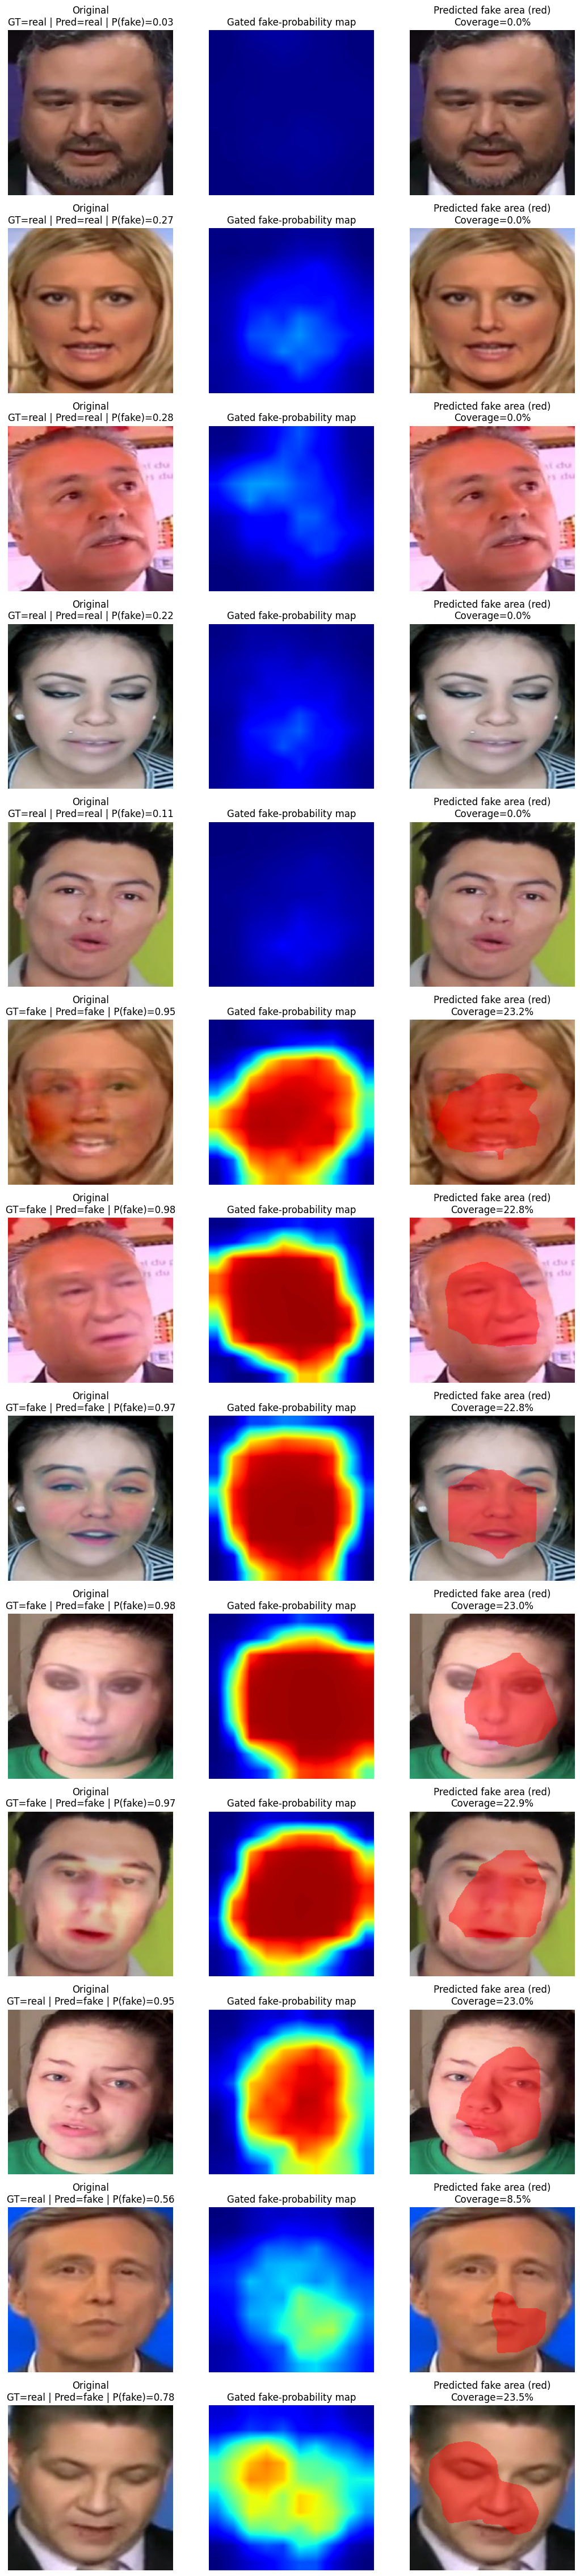

In [27]:
import matplotlib.pyplot as plt
import numpy as np

show_loc_examples(
    model_loc,
    testloader,
    class_to_idx,
    n_real_ok=5,
    n_fake_ok=5,
    n_fail=3,
    alpha=0.45,
    thr=0.55
)

In [28]:
rgb_norm = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])

valset = FFPPVideoFramesDataset(
    "/kaggle/working/FF_aligned_faces/val",
    compression="c23",
    train=False,
    jpeg_aug=None,
    rgb_color_aug=None,
    rgb_norm=rgb_norm
)

valloader = DataLoader(valset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

[FFPPVideoFramesDataset] samples=500 | real=100 | fake=400


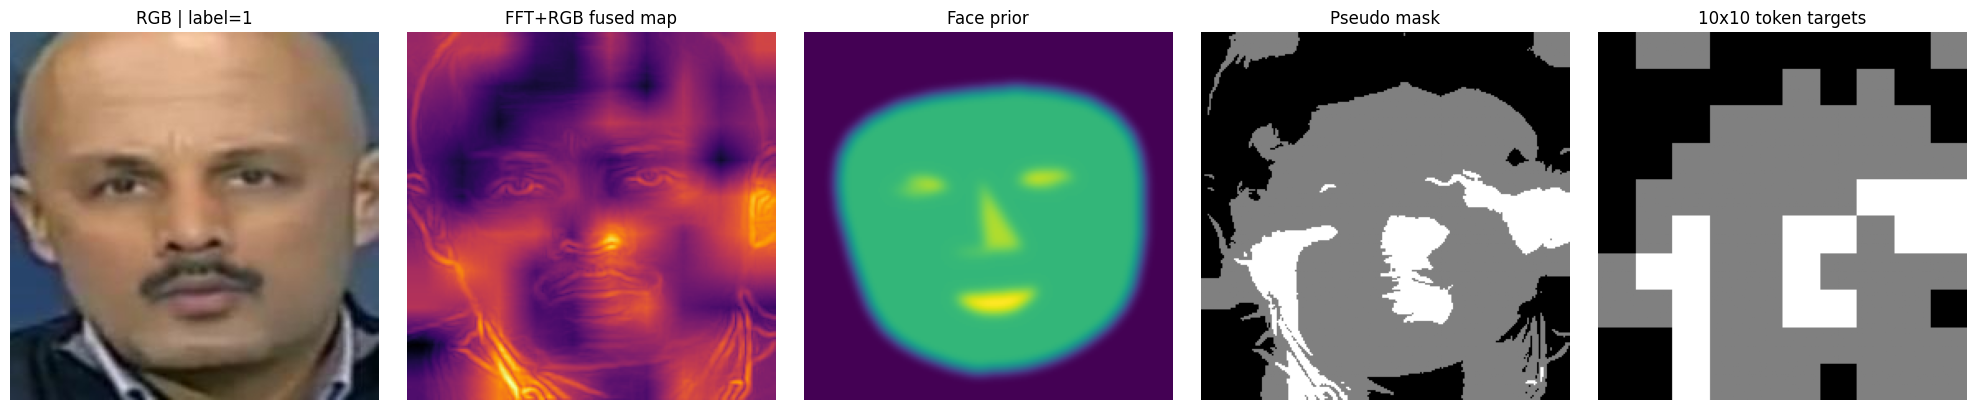

token counts: {-100: 55, 0: 29, 1: 16}
--------------------------------------------------------------------------------


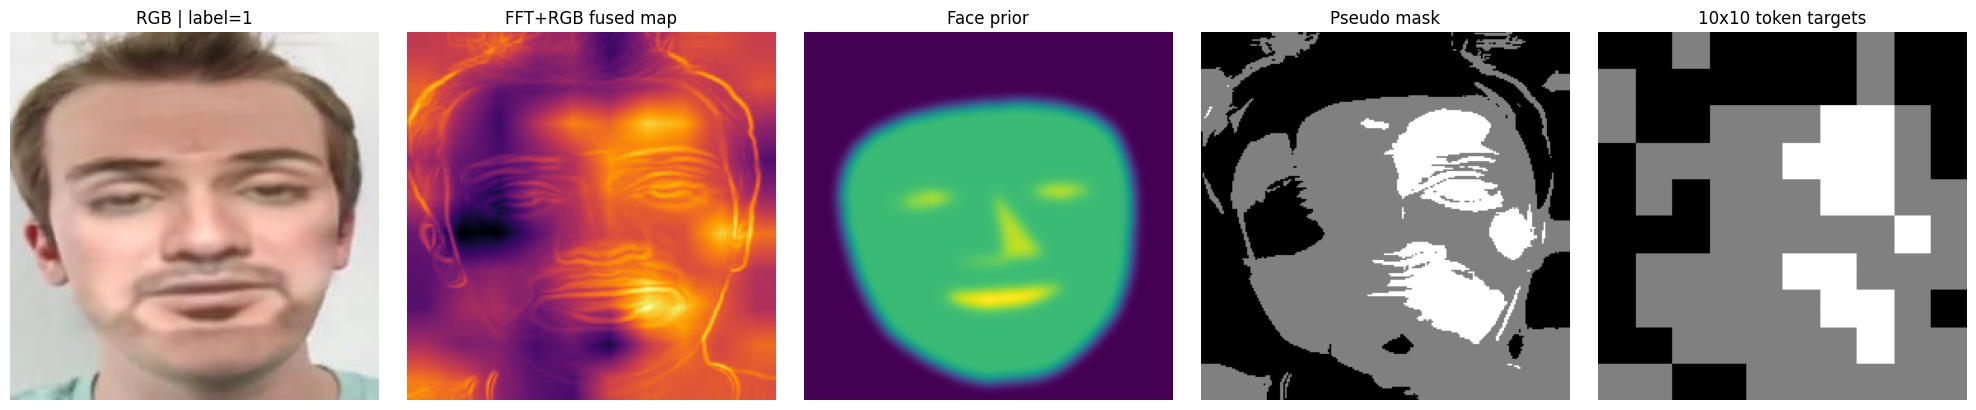

token counts: {-100: 54, 0: 33, 1: 13}
--------------------------------------------------------------------------------


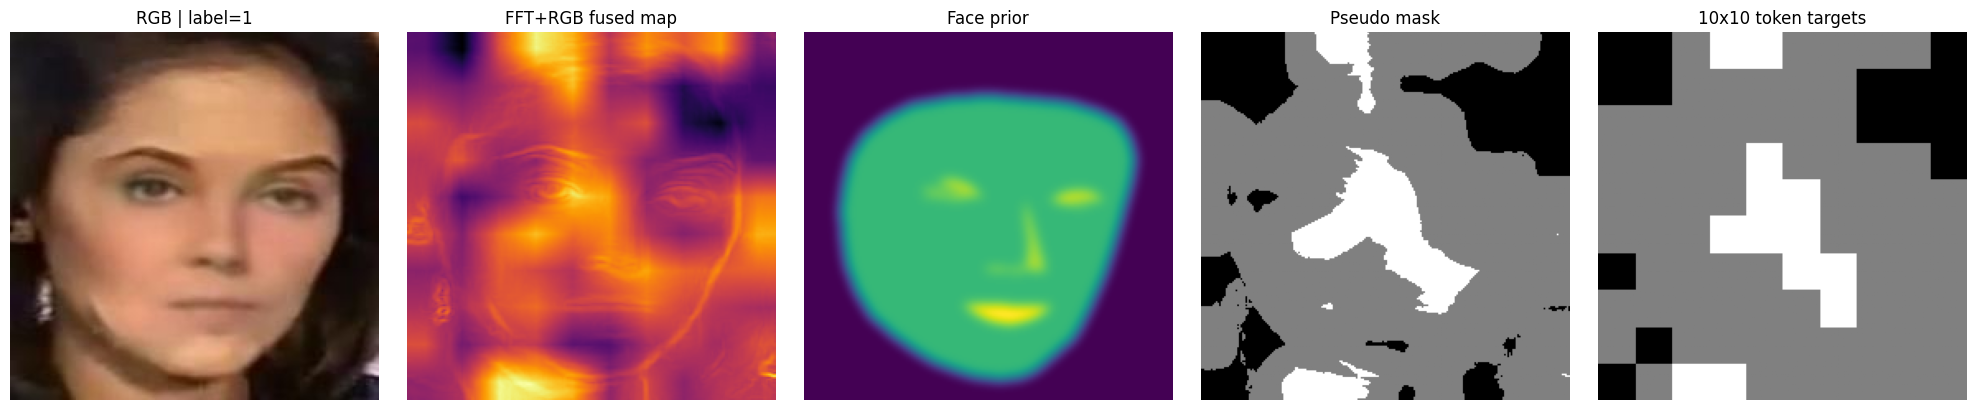

token counts: {-100: 72, 0: 15, 1: 13}
--------------------------------------------------------------------------------


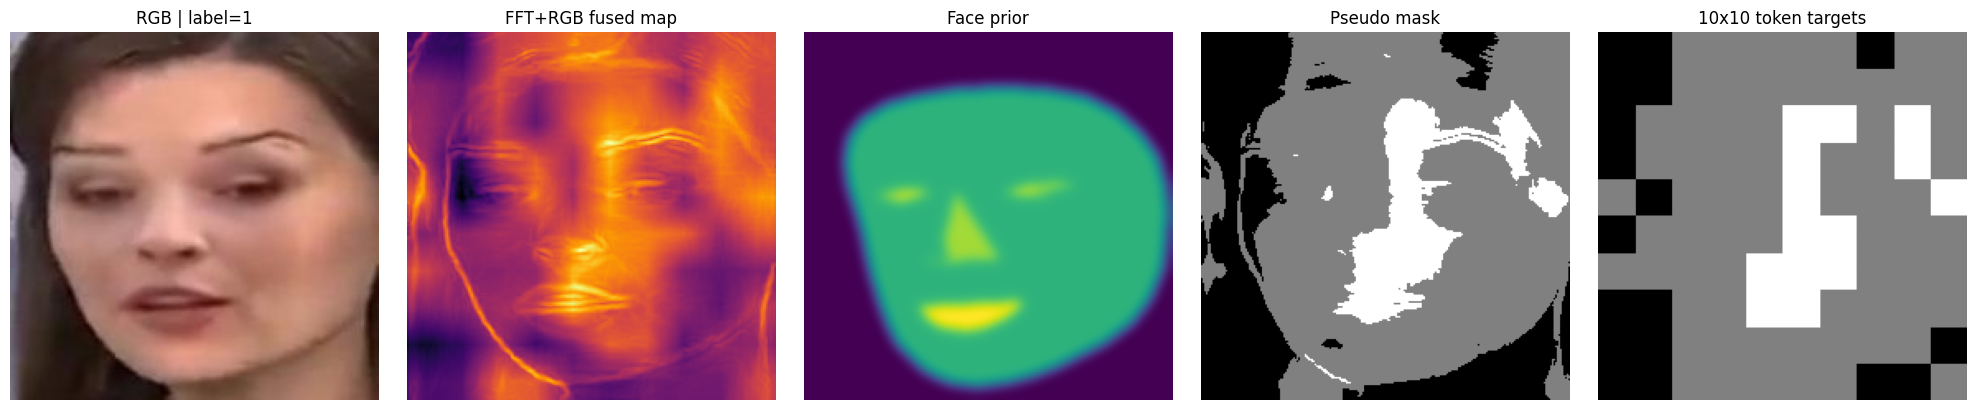

token counts: {-100: 68, 0: 18, 1: 14}
--------------------------------------------------------------------------------


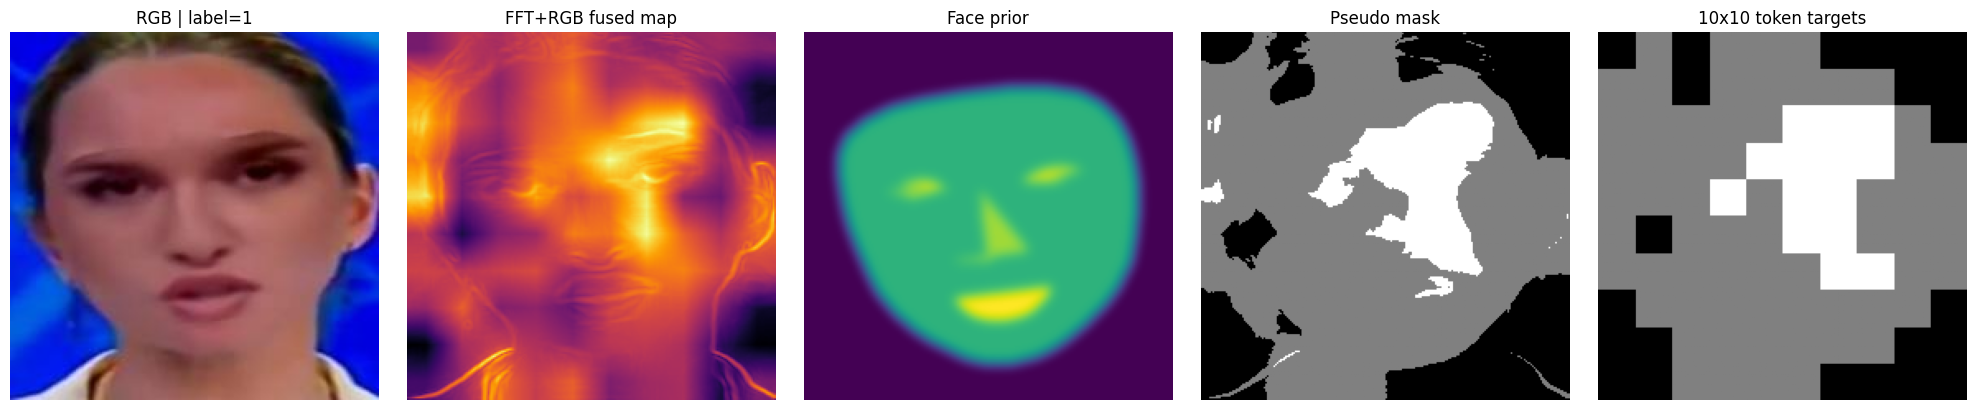

token counts: {-100: 63, 0: 23, 1: 14}
--------------------------------------------------------------------------------


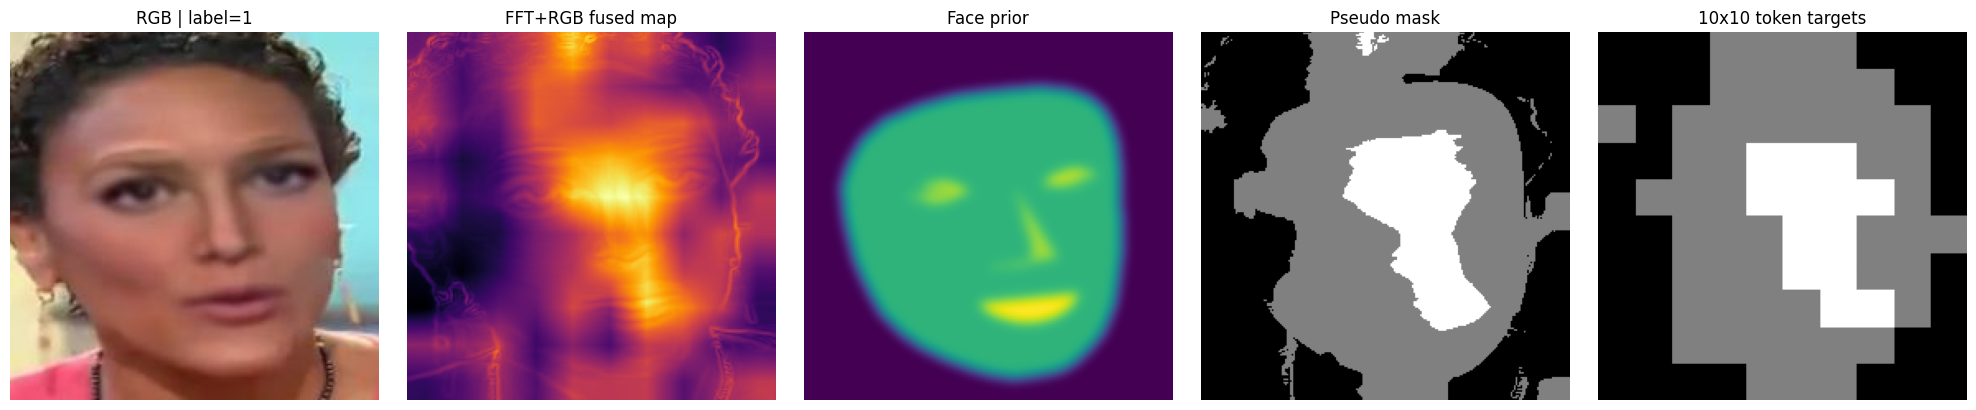

token counts: {-100: 50, 0: 37, 1: 13}
--------------------------------------------------------------------------------


In [29]:
debug_faceaware_localisation(
    model_loc,
    valloader,
    device,
    num_samples=6,
    fake_idx=1,
    show_real=False
)